# 🚀 Zero-Shot Image Segmentation with CLIPSeg

This notebook implements image segmentation based on text prompts using the `CIDAS/clipseg-rd64-refined` model. 
It processes all images in the `imagens` folder in a bulk operation.

In [1]:
# Install dependencies
%pip install transformers torch torchvision pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 🛠️ Configuração e Carregamento do Modelo

Vamos carregar o processador e o modelo pré-treinado `CIDAS/clipseg-rd64-refined`.

In [2]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

# Carregando o modelo e o processador
MODEL_NAME = "CIDAS/clipseg-rd64-refined"
processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)
model = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Modelo carregado no: {device}")

c:\Users\ivanu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 462/462 [00:00<00:00, 2827.78it/s]
CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from diff

Modelo carregado no: cpu


## 🖼️ Processamento das Imagens

Agora vamos percorrer a pasta `imagens`, aplicar a segmentação baseada em prompts de texto e exibir os resultados.


Processando: bird.jpg...


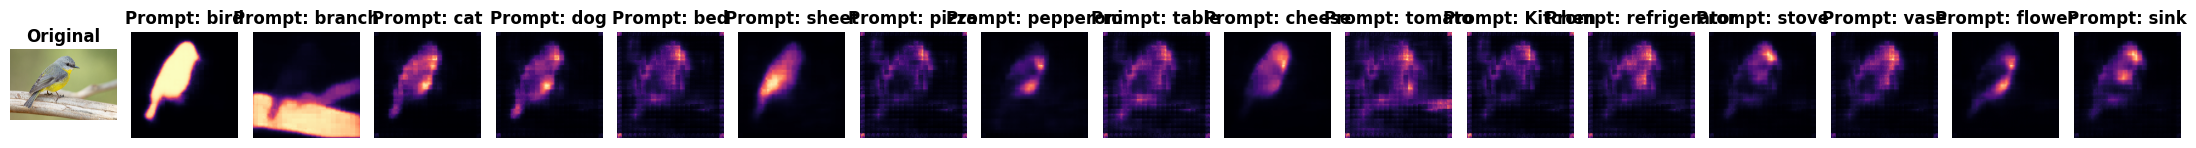


Processando: cats_dog.png...


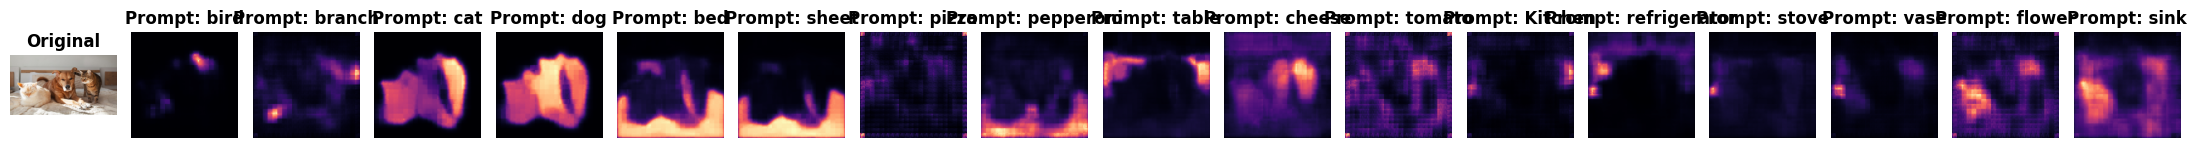


Processando: kitchen.png...


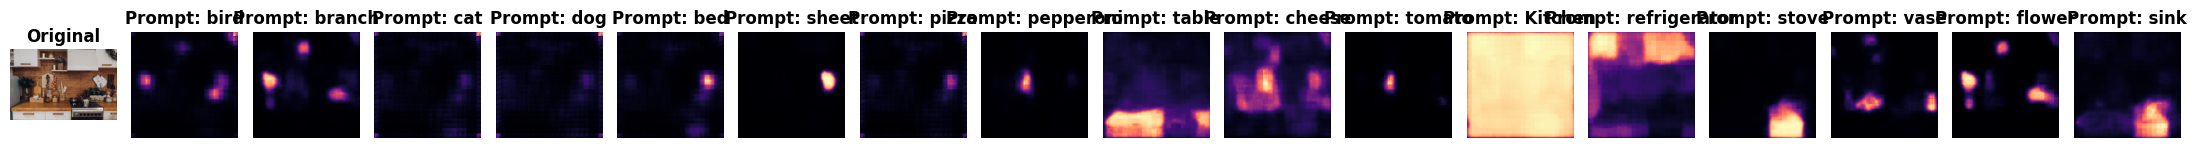


Processando: pizza.png...


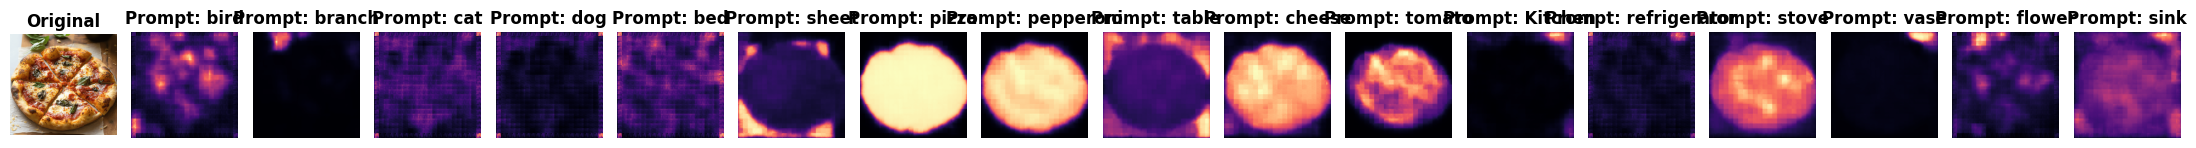

In [3]:
# Configurações de caminhos
IMAGES_DIR = r'C:\Users\ivanu\Desktop\recog_system\imagens'
prompts = ["bird", "branch", "cat", "dog", "bed", "sheet", "pizza", "pepperoni", "table", "cheese", "tomato", "Kitchen", "refrigerator", "stove", "vase", "flower", "sink"] 
          

def segment_image(image_path, prompts):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Sigmoid converte os logits em máscaras de probabilidade
    preds = torch.sigmoid(outputs.logits)
    return image, preds

# Listar e segmentar imagens
valid_exts = (".png", ".jpg", ".jpeg")
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(valid_exts)]

for img_name in image_files:
    full_path = os.path.join(IMAGES_DIR, img_name)
    print(f"\nProcessando: {img_name}...")
    
    original_img, masks = segment_image(full_path, prompts)
    
    # Visualização estilizada
    n_prompts = len(prompts)
    fig, ax = plt.subplots(1, n_prompts + 1, figsize=(22, 6))
    
    ax[0].imshow(original_img)
    ax[0].set_title("Original", fontweight='bold')
    ax[0].axis("off")
    
    for i, p in enumerate(prompts):
        m = masks[i].cpu().numpy()
        ax[i+1].imshow(m, cmap='magma')
        ax[i+1].set_title(f"Prompt: {p}", fontweight='bold')
        ax[i+1].axis("off")
    
    plt.tight_layout()
    plt.show()